The Ship Performance Dataset is a synthetic yet realistic collection of data designed to represent key operational metrics and attributes of various ship types in the Gulf of Guinea. This dataset is tailored for maritime data analytics enthusiasts, machine learning practitioners, and professionals interested in exploring clustering, prediction, and optimization problems in the maritime industry.

https://www.kaggle.com/datasets/jeleeladekunlefijabi/ship-performance-clustering-dataset


## Aprendizaje No Supervisado (K-Means)



### 1. Importación de Librerías y CSV


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/SAA/Ship_Performance_Dataset.csv")

### 2. Análisis Exploratorio

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   object 
 1   Ship_Type                2600 non-null   object 
 2   Route_Type               2600 non-null   object 
 3   Engine_Type              2600 non-null   object 
 4   Maintenance_Status       2600 non-null   object 
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   object 
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Efficiency_nm_per_kWh   

In [ ]:
df.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [ ]:
df.describe()

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
count,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000
mean,17.602863,1757.610939,1036.406203,9.929103,1032.573264,255143.344488,521362.062011,41.747536,0.798656,1.003816,4.914839,75.219222
std,4.311979,717.002777,568.632080,2.876423,558.697499,140890.482189,271211.625499,17.633130,0.403590,0.288251,2.597647,14.510168
min,10.009756,501.025220,50.433150,5.001947,50.229624,10092.306318,50351.814447,12.019909,0.100211,0.500004,1.000000,50.012005
25%,13.928452,1148.104914,548.511573,7.437485,553.983629,131293.378767,290346.388017,26.173537,0.463592,0.758033,3.000000,62.703724
50%,17.713757,1757.494344,1037.816060,9.918965,1043.207497,257157.653226,520176.931762,41.585188,0.789877,1.009009,5.000000,75.504709
75%,21.284785,2382.594292,1540.934161,12.413149,1527.722391,381796.930499,750072.791216,57.363922,1.147426,1.252808,7.000000,87.721205
max,24.997043,2998.734329,1998.337057,14.992947,1999.126697,499734.867868,999916.696140,71.972415,1.499259,1.499224,9.000000,99.999643


In [ ]:
df.isna().sum()

,0
Date,0
Ship_Type,136
Route_Type,136
Engine_Type,136
Maintenance_Status,136
Speed_Over_Ground_knots,0
Engine_Power_kW,0
Distance_Traveled_nm,0
Draft_meters,0
Weather_Condition,136


In [ ]:
# Seleccionamos variables clave de rendimiento y coste
features = [
    'Engine_Power_kW',
    'Operational_Cost_USD',
    'Efficiency_nm_per_kWh',
    'Revenue_per_Voyage_USD',
    'Average_Load_Percentage'
]

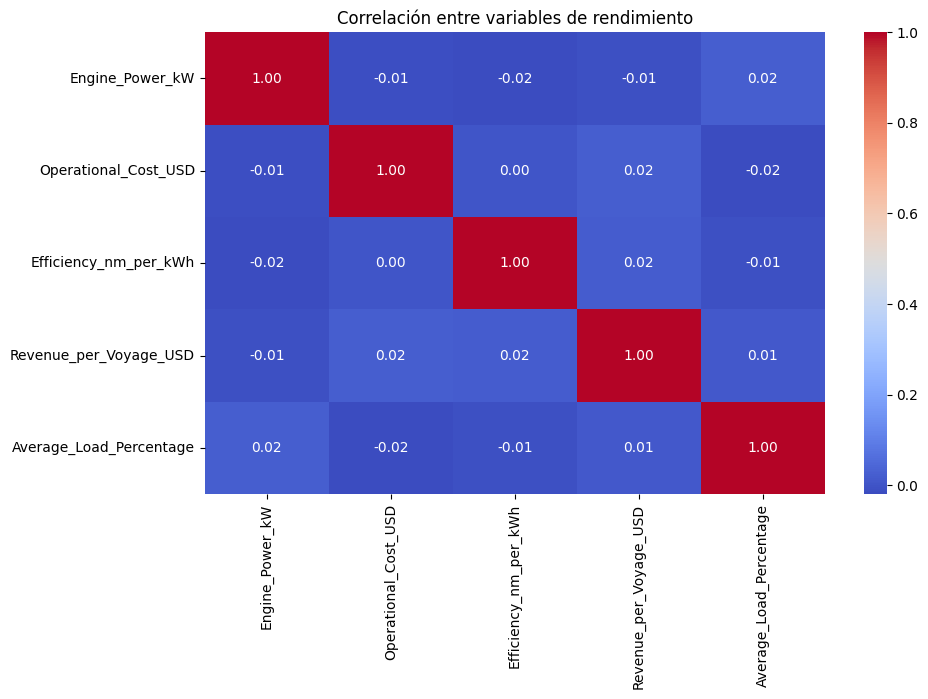

In [ ]:
df_clustering = df[features]

# 2.3 Visualización de correlaciones (Mapa de calor)
plt.figure(figsize=(10, 6))
sns.heatmap(df_clustering.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre variables de rendimiento")
plt.show()

In [ ]:
# Verificar si hay valores nulos en nuestra selección
if df_clustering.isnull().values.any():
    df_clustering = df_clustering.dropna()


### 3. Preprocesamiento de Datos

In [ ]:
# Escalado de datos (Estandarización)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Convertir de nuevo a DataFrame para facilitar el manejo posterior
df_scaled = pd.DataFrame(df_scaled, columns=features)

df_scaled.head()

,Engine_Power_kW,Operational_Cost_USD,Efficiency_nm_per_kWh,Revenue_per_Voyage_USD,Average_Load_Percentage
0,0.425980,1.623465,1.627007,-0.845173,1.278649
1,0.053631,1.620311,-1.259663,1.336484,1.287343
2,-0.152125,1.372949,-0.741138,-0.469621,1.447458
3,-1.175035,0.044058,-0.237289,-1.599821,-0.622127
4,-0.931672,0.231250,1.320115,0.570727,0.330130



### 4. Determinación del Número Óptimo de Clústers ()

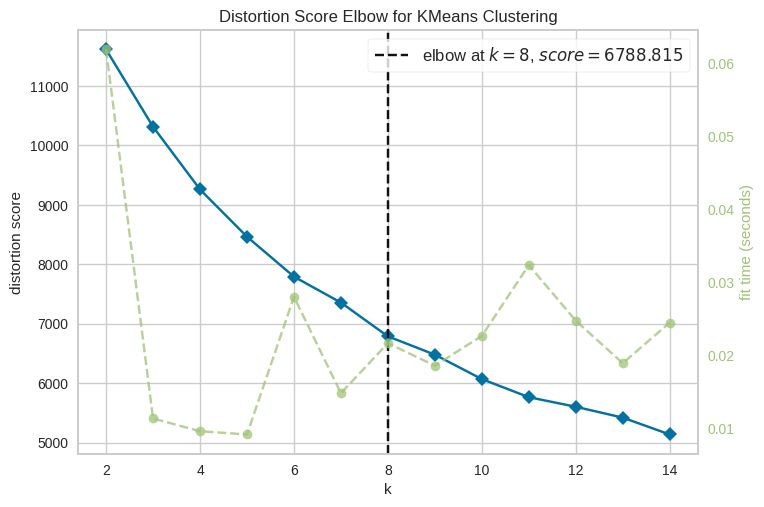

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(2,15))
visualizer.fit(df_scaled)
visualizer.poof()

Según el gráfico 8 es el número idóneo de clústeres, que se corresponderían con ...


### 5. Entrenamiento del Modelo K-Means

* **Inicialización:** Configuración de centroides y parámetros del algoritmo.
* **Ajuste (Fit):** Ejecución del modelo sobre los datos preprocesados.

In [ ]:
# Definir el número de clústers óptimo
n_clusters_optimo = 8

# Entrenar el modelo
kmeans = KMeans(n_clusters=n_clusters_optimo, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Asignar los clústers al DataFrame original para análisis
df['Cluster_ID'] = clusters

print(f"Modelo entrenado con {n_clusters_optimo} clústers.")
print(df[['Ship_Type', 'Operational_Cost_USD', 'Cluster_ID']].head())

Modelo entrenado con 8 clústers.
        Ship_Type  Operational_Cost_USD  Cluster_ID
0  Container Ship         483832.354540           5
1    Fish Carrier         483388.000509           3
2  Container Ship         448543.404044           3
3    Bulk Carrier         261349.605449           6
4    Fish Carrier         287718.375160           5



### 6. Análisis y Categorización de Resultados

* **Asignación de Etiquetas:** Creación de una nueva columna en el DataFrame original con el clúster asignado.
* **Visualización de Grupos:** Creación de gráficos de dispersión (*scatter plots*) comparando variables clave.
* **Perfilamiento de Clústers:** Análisis de las características promedio de cada grupo encontrado.


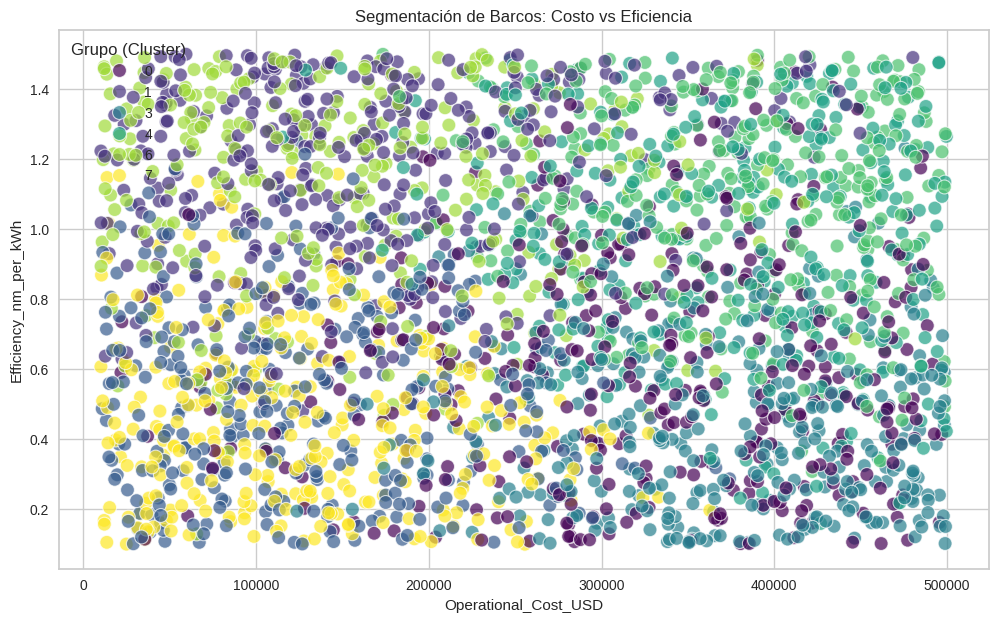

In [ ]:
# 6.1 Visualización de Clústers: Costo vs Eficiencia
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=df['Operational_Cost_USD'],
    y=df['Efficiency_nm_per_kWh'],
    hue=df['Cluster_ID'],
    palette='viridis',
    s=100,
    alpha=0.7
)

plt.title('Segmentación de Barcos: Costo vs Eficiencia')
plt.legend(title='Grupo (Cluster)')
plt.show()

In [ ]:
# 6.2 Análisis de los perfiles (Promedios por Clúster)
perfil_clusters = df.groupby('Cluster_ID')[features].mean()
display(perfil_clusters)

,Engine_Power_kW,Operational_Cost_USD,Efficiency_nm_per_kWh,Revenue_per_Voyage_USD,Average_Load_Percentage
Cluster_ID,,,,,
0,1120.066471,322130.609284,0.601643,714725.986535,62.502380
1,2075.705381,166976.389086,1.174983,753526.851832,82.480926
2,1345.067182,127780.483050,0.518137,458282.213248,88.445256
3,2190.781482,371425.778690,0.451238,513729.546626,86.744680
4,2382.662062,371190.130913,0.993407,451292.268789,62.014590
5,1276.345473,381212.598437,1.081006,449539.552350,85.945982
6,1256.101899,161038.162101,1.107332,307801.749358,64.262174
7,2400.114770,129134.527762,0.462703,435249.160480,67.314043
